# Topic Modeling - LDA & BERTopic

Notebook ini melakukan topic modeling menggunakan dua pendekatan:
1. **LDA (Latent Dirichlet Allocation)** - uji beberapa jumlah topik (k)
2. **BERTopic** - clustering berbasis embedding

**Catatan**: Menggunakan 50% sampling dari dataset untuk meringankan perangkat saat fitting model.

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import silhouette_score
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

import os

os.makedirs('output', exist_ok=True)

## 2. Load Data & Sampling 50%

In [2]:
df = pd.read_csv('data/representasi.csv')
print(f"Dataset asli: {len(df)} baris")
print(f"Kolom: {df.columns.tolist()}")
df.head()

Dataset asli: 13574 baris
Kolom: ['text', 'diggCount', 'replyCommentTotal', 'createTimeISO', 'uniqueId', 'text_final', 'lda_topic', 'lda_topic_prob', 'lda_topic_words', 'bertopic_topic', 'bertopic_topic_prob', 'bertopic_topic_words']


,text,diggCount,replyCommentTotal,createTimeISO,uniqueId,text_final,lda_topic,lda_topic_prob,lda_topic_words,bertopic_topic,bertopic_topic_prob,bertopic_topic_words
0,aav,0,0,2026-01-17T11:58:59.000Z,carisiapayaka,aav,0,0.066667,omon | betul | masya_allah | ya | wowo | curha...,-1,0.0,No Topic
1,pretttttt,3,0,2025-11-16T15:36:05.000Z,preittyiesss00,pretttttt,0,0.066667,omon | betul | masya_allah | ya | wowo | curha...,-1,0.0,No Topic
2,halah,0,0,2025-11-17T01:18:02.000Z,buanamooz,halah,13,0.533333,omon_omon | ladang | korup | halah | salah_gun...,-1,0.0,No Topic
3,KOCAK LU AH,0,0,2025-11-16T15:13:02.000Z,oohsehuni3,kocak anda ah,4,0.509537,ah | ganti_uang | kocak | mengejek | tag | dos...,-1,0.0,No Topic
4,MBG?,1,0,2025-11-16T16:30:43.000Z,xoxx0o,makan bergizi gratis,5,0.711553,makan | gratis | bergizi | yang | bergizi grat...,-1,0.0,No Topic


In [3]:
df_sampled = df.sample(frac=0.5, random_state=42).reset_index(drop=True)
print(f"Dataset setelah sampling 50%: {len(df_sampled)} baris")
df_sampled.head()

Dataset setelah sampling 50%: 6787 baris


,text,diggCount,replyCommentTotal,createTimeISO,uniqueId,text_final,lda_topic,lda_topic_prob,lda_topic_words,bertopic_topic,bertopic_topic_prob,bertopic_topic_words
0,"mbg gak hanya buat anak sekolah ya gaes, ibu h...",3,3,2025-11-20T01:56:30.000Z,shanmarys,makan bergizi gratis tidak hanya buat anak sek...,5,0.813567,makan | gratis | bergizi | yang | bergizi grat...,-1,0.0,No Topic
1,sbnrnya program mbg bagus yg meruesakny yg men...,0,0,2026-01-13T02:02:10.000Z,tya371,sbnrnya program makan bergizi gratis bagus yan...,5,0.833103,makan | gratis | bergizi | yang | bergizi grat...,-1,0.0,No Topic
2,"aku guru paud, sangat senang dengan program mb...",3,0,2025-12-05T08:54:09.000Z,ayaisback_,saya guru paud sangat senang dengan program ma...,5,0.886448,makan | gratis | bergizi | yang | bergizi grat...,-1,0.0,No Topic
3,mbg anak2 jadi semangat sekolah... the best p ...,0,0,2025-11-15T08:59:41.000Z,akbarnaluri,makan bergizi gratis anak jadi semangat sekola...,5,0.582227,makan | gratis | bergizi | yang | bergizi grat...,-1,0.0,No Topic
4,lanjut MBG terus pak Prabowo sampai selama-lam...,1,0,2026-01-08T08:24:36.000Z,tokorshi78,lanjut makan bergizi gratis terus bapak_prabow...,5,0.772063,makan | gratis | bergizi | yang | bergizi grat...,-1,0.0,No Topic


In [4]:
texts = df_sampled['text_final'].fillna('').astype(str).tolist()
texts = [t for t in texts if len(t.strip()) > 0]
print(f"Jumlah dokumen valid: {len(texts)}")

Jumlah dokumen valid: 6787


## 3. LDA - Uji Beberapa Jumlah Topik (k)

In [5]:
vectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=10000)
doc_term_matrix = vectorizer.fit_transform(texts)
print(f"Shape Document-Term Matrix: {doc_term_matrix.shape}")

Shape Document-Term Matrix: (6787, 4599)


In [6]:
k_values = [5, 8, 10, 12, 15, 20]
lda_models = {}
lda_results = []

tokens_list = [t.split() for t in texts]
dictionary = Dictionary(tokens_list)
dictionary.filter_extremes(no_below=2, no_above=0.95)
corpus = [dictionary.doc2bow(token) for token in tokens_list]

for k in k_values:
    print(f"\nTraining LDA dengan k={k}...")
    
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        learning_method='online',
        learning_offset=50.,
        max_iter=10,
        batch_size=128,
        evaluate_every=-1
    )
    lda.fit(doc_term_matrix)
    lda_models[k] = lda
    
    perplexity = lda.perplexity(doc_term_matrix)
    
    topic_words = []
    for topic_idx, topic in enumerate(lda.components_):
        top_words = [vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]]
        topic_words.append(top_words)
    
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokens_list,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence = coherence_model.get_coherence()
    
    log_likelihood = lda.score(doc_term_matrix)
    
    unique_words = set()
    total_words = 0
    for tw in topic_words:
        unique_words.update(tw)
        total_words += len(tw)
    topic_diversity = len(unique_words) / total_words if total_words > 0 else 0
    
    lda_results.append({
        'k': k,
        'perplexity': perplexity,
        'coherence': coherence,
        'log_likelihood': log_likelihood,
        'topic_diversity': topic_diversity
    })
    
    print(f"  Perplexity: {perplexity:.2f}")
    print(f"  Coherence (C_v): {coherence:.4f}")
    print(f"  Log-Likelihood: {log_likelihood:.2f}")
    print(f"  Topic Diversity: {topic_diversity:.4f}")
    print(f"  Top 5 kata topik 0: {', '.join(topic_words[0][:5])}")


Training LDA dengan k=5...
  Perplexity: 764.99
  Coherence (C_v): 0.5068
  Log-Likelihood: -606265.69
  Topic Diversity: 0.9000
  Top 5 kata topik 0: gizi, pangan, pelayanan, mokel, tahu

Training LDA dengan k=8...
  Perplexity: 799.22
  Coherence (C_v): 0.5098
  Log-Likelihood: -610262.79
  Topic Diversity: 0.9000
  Top 5 kata topik 0: tahu, min, bpk_prabowo, omon, masya_allah

Training LDA dengan k=10...
  Perplexity: 828.40
  Coherence (C_v): 0.4782
  Log-Likelihood: -613536.58
  Topic Diversity: 0.9100
  Top 5 kata topik 0: tahu, pemimpin, wo, kapan, jangan

Training LDA dengan k=12...
  Perplexity: 851.37
  Coherence (C_v): 0.4656
  Log-Likelihood: -616033.88
  Topic Diversity: 0.9333
  Top 5 kata topik 0: mah, wo, lahan_korupsi, ko, tuhan

Training LDA dengan k=15...
  Perplexity: 876.96
  Coherence (C_v): 0.4752
  Log-Likelihood: -618738.38
  Topic Diversity: 0.8867
  Top 5 kata topik 0: uda, love, mengerti, lowongan_kerja, yo

Training LDA dengan k=20...
  Perplexity: 909.35


In [7]:
results_df = pd.DataFrame(lda_results)
results_df.to_csv('output/lda_evaluation_results.csv', index=False)
results_df

,k,perplexity,coherence,log_likelihood,topic_diversity
0,5,764.987803,0.506777,-606265.686932,0.900000
1,8,799.220142,0.509753,-610262.791483,0.900000
2,10,828.395877,0.478227,-613536.578687,0.910000
3,12,851.365677,0.465593,-616033.878700,0.933333
4,15,876.960178,0.475153,-618738.377923,0.886667
5,20,909.348790,0.430043,-622049.821984,0.955000


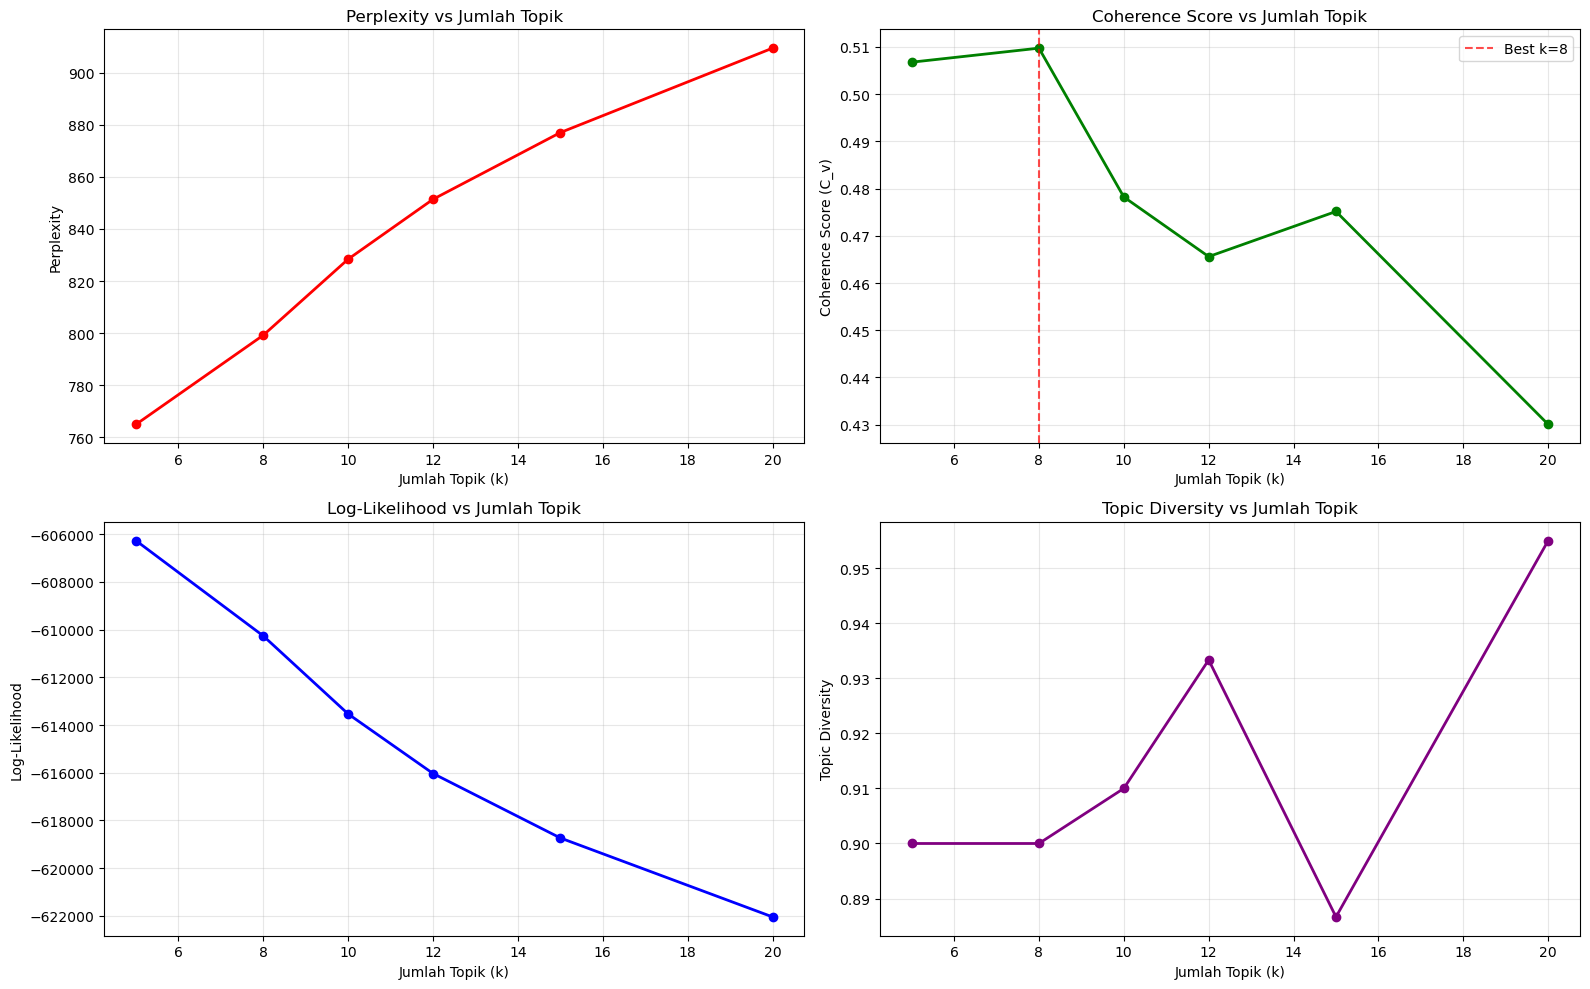

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(results_df['k'], results_df['perplexity'], marker='o', linewidth=2, color='red')
axes[0, 0].set_xlabel('Jumlah Topik (k)')
axes[0, 0].set_ylabel('Perplexity')
axes[0, 0].set_title('Perplexity vs Jumlah Topik')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(results_df['k'], results_df['coherence'], marker='o', linewidth=2, color='green')
best_k_idx = results_df['coherence'].idxmax()
best_k = results_df.loc[best_k_idx, 'k']
axes[0, 1].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
axes[0, 1].set_xlabel('Jumlah Topik (k)')
axes[0, 1].set_ylabel('Coherence Score (C_v)')
axes[0, 1].set_title('Coherence Score vs Jumlah Topik')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(results_df['k'], results_df['log_likelihood'], marker='o', linewidth=2, color='blue')
axes[1, 0].set_xlabel('Jumlah Topik (k)')
axes[1, 0].set_ylabel('Log-Likelihood')
axes[1, 0].set_title('Log-Likelihood vs Jumlah Topik')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(results_df['k'], results_df['topic_diversity'], marker='o', linewidth=2, color='purple')
axes[1, 1].set_xlabel('Jumlah Topik (k)')
axes[1, 1].set_ylabel('Topic Diversity')
axes[1, 1].set_title('Topic Diversity vs Jumlah Topik')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/lda_k_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
print(f"Jumlah topik optimal berdasarkan Coherence Score: k = {best_k}")
best_lda = lda_models[best_k]

feature_names = vectorizer.get_feature_names_out()
n_top_words = 15

print(f"\n=== Topik dari LDA dengan k={best_k} ===\n")
for topic_idx, topic in enumerate(best_lda.components_):
    top_words_idx = topic.argsort()[:-n_top_words-1:-1]
    top_words = [feature_names[i] for i in top_words_idx]
    top_probs = [topic[i] for i in top_words_idx]
    print(f"Topik {topic_idx}:")
    print(f"  Kata kunci: {' | '.join(top_words)}")
    print(f"  Probabilitas: {[f'{p:.4f}' for p in top_probs]}\n")

Jumlah topik optimal berdasarkan Coherence Score: k = 8

=== Topik dari LDA dengan k=8 ===

Topik 0:
  Kata kunci: tahu | min | bpk_prabowo | omon | masya_allah | bayar | ternyata | kuliah | pajak | nama | insyaallah | untk | hormat | hnya | love
  Probabilitas: ['76.0259', '60.5590', '47.8017', '22.5136', '21.8711', '18.5076', '15.7158', '14.8612', '14.4959', '14.2509', '12.0696', '11.6658', '11.2048', '10.6385', '10.1576']

Topik 1:
  Kata kunci: pk | mokel | maju | lanjut | demi | ya_allah | sehat | bapak_prabowo | jalan | anak_bangsa | mari | maka | hebat | siap | alhamdulilah
  Probabilitas: ['92.3785', '82.8051', '43.0290', '41.7257', '36.7279', '36.3335', '33.9027', '33.8072', '31.0730', '30.7885', '23.3991', '22.5206', '22.4109', '21.4891', '19.6618']

Topik 2:
  Kata kunci: makan | gratis | bergizi | yang | saya | tidak | di | anak | bapak | nya | ada | saja | kalau | dan | karena
  Probabilitas: ['4016.3486', '3304.0686', '3245.0254', '2214.2439', '2152.5471', '1415.5190', '1

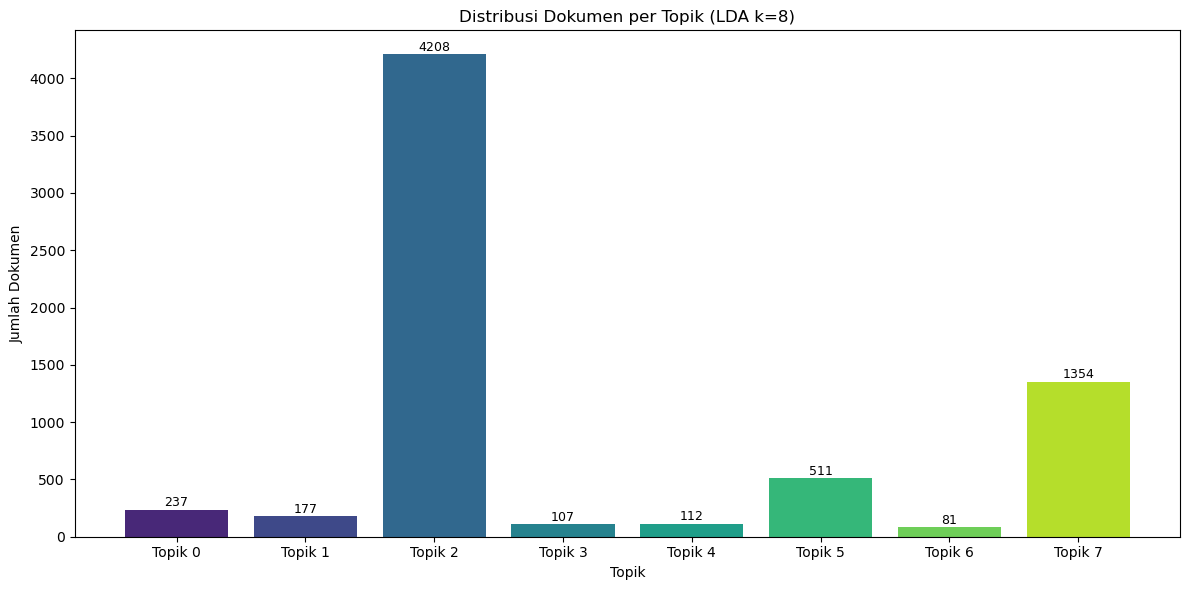

In [10]:
doc_topics = best_lda.transform(doc_term_matrix)
df_sampled['lda_best_topic'] = doc_topics.argmax(axis=1)
df_sampled['lda_best_prob'] = doc_topics.max(axis=1)

topic_counts = df_sampled['lda_best_topic'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(topic_counts)), topic_counts.values, color=sns.color_palette('viridis', len(topic_counts)))
plt.xlabel('Topik')
plt.ylabel('Jumlah Dokumen')
plt.title(f'Distribusi Dokumen per Topik (LDA k={best_k})')
plt.xticks(range(len(topic_counts)), [f'Topik {i}' for i in range(len(topic_counts))])

for bar, count in zip(bars, topic_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
             f'{count}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('output/lda_best_topic_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

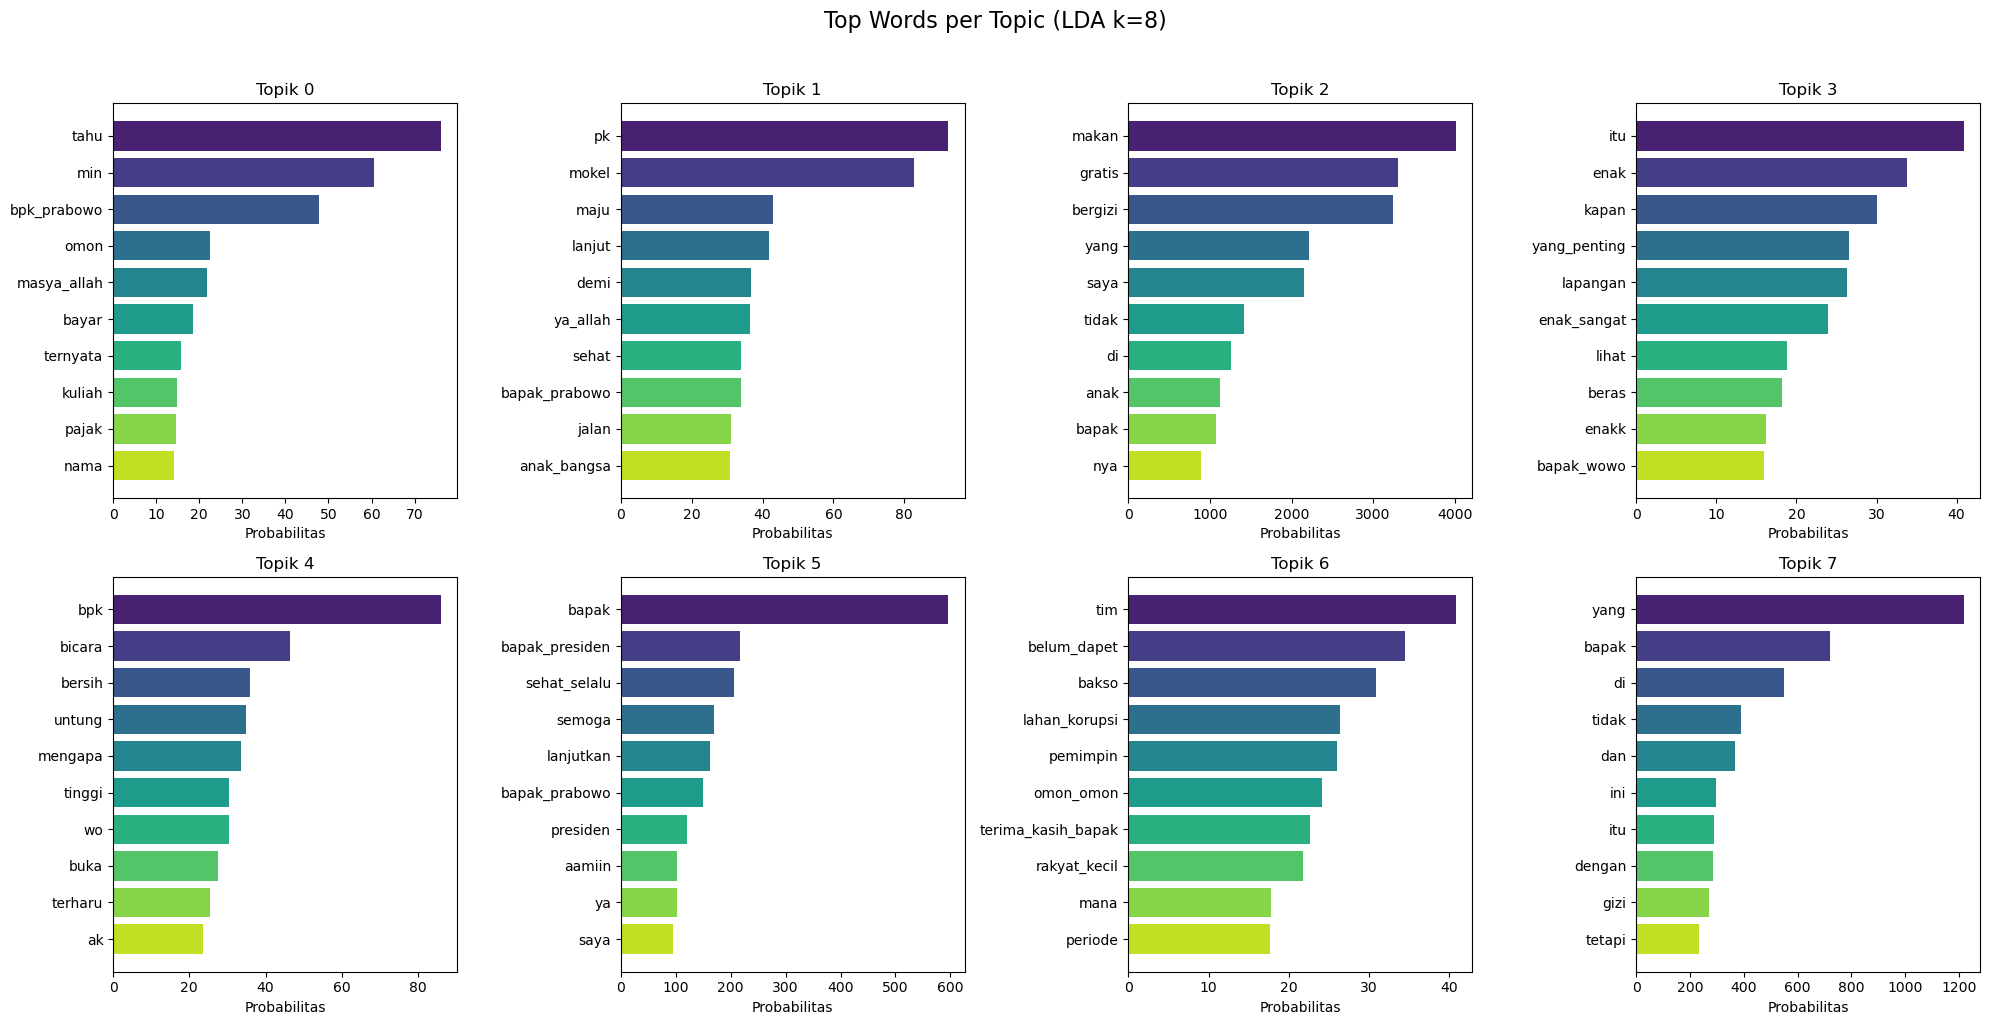

In [11]:
fig, axes = plt.subplots(2, (best_k+1)//2, figsize=(20, 10))
if best_k == 1:
    axes = [axes]
axes = axes.flatten()

for topic_idx in range(best_k):
    topic_words_idx = best_lda.components_[topic_idx].argsort()[:-11:-1]
    top_words = [feature_names[i] for i in topic_words_idx]
    top_probs = best_lda.components_[topic_idx][topic_words_idx]
    
    axes[topic_idx].barh(range(len(top_words)), top_probs, color=sns.color_palette('viridis', len(top_words)))
    axes[topic_idx].set_yticks(range(len(top_words)))
    axes[topic_idx].set_yticklabels(top_words)
    axes[topic_idx].invert_yaxis()
    axes[topic_idx].set_title(f'Topik {topic_idx}')
    axes[topic_idx].set_xlabel('Probabilitas')

for j in range(topic_idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Top Words per Topic (LDA k={best_k})', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('output/lda_top_words_per_topic.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. BERTopic - Clustering Berbasis Embedding

In [12]:
print("Memuat model sentence transformer (multilingual)...")
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print("Model berhasil dimuat.")

Memuat model sentence transformer (multilingual)...
Model berhasil dimuat.


In [13]:
print("Fitting BERTopic...")
topic_model = BERTopic(
    embedding_model=embedding_model,
    language='indonesian',
    nr_topics='auto',
    top_n_words=15,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(texts)
print(f"BERTopic selesai. Jumlah topik ditemukan: {len(set(topics)) - (1 if -1 in topics else 0)}")
print(f"Jumlah outlier (-1): {topics.count(-1)}")

2026-05-04 11:34:51,680 - BERTopic - Embedding - Transforming documents to embeddings.


Fitting BERTopic...


Batches:   0%|          | 0/213 [00:00<?, ?it/s]

2026-05-04 11:35:39,463 - BERTopic - Embedding - Completed ✓
2026-05-04 11:35:39,464 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-04 11:36:11,015 - BERTopic - Dimensionality - Completed ✓
2026-05-04 11:36:11,016 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-04 11:36:14,008 - BERTopic - Cluster - Completed ✓
2026-05-04 11:36:14,009 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-04 11:36:14,191 - BERTopic - Representation - Completed ✓
2026-05-04 11:36:14,192 - BERTopic - Topic reduction - Reducing number of topics
2026-05-04 11:36:14,221 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-04 11:36:14,340 - BERTopic - Representation - Completed ✓
2026-05-04 11:36:14,344 - BERTopic - Topic reduction - Reduced number of topics from 101 to 25


BERTopic selesai. Jumlah topik ditemukan: 24
Jumlah outlier (-1): 2345


In [14]:
topic_info = topic_model.get_topic_info()
print(topic_info)

    Topic  Count                                               Name  \
0      -1   2345                       -1_makan_yang_bergizi_gratis   
1       0   3622                        0_makan_gratis_bergizi_saya   
2       1    122            1_indonesia_rakyat_indonesia_semoga_dan   
3       2    121             2_korupsi_koruptor_lahan_korupsi_korup   
4       3     71                     3_program_bagus_programnya_nya   
5       4     52  4_kerja_ekonomi_lapangan_kerja_lapangan_pekerjaan   
6       5     45                          5_bpk_bpk_prabowo_bp_yang   
7       6     39                    6_bos_kerja_info_lowongan_aslap   
8       7     39                        7_menangis_beliau_sedih_air   
9       8     31                  8_program_program_ini_bapak_bagus   
10      9     30                        9_tim_yang_belum_dapet_team   
11     10     28        10_selalu_selalu_habis_selalu_abis_alasanku   
12     11     25                       11_omon_omon_omon_mulu_bosan   
13    

In [15]:
bertopic_coherence = None
bertopic_topic_diversity = None

real_topics_list = [t for t in set(topics) if t != -1]
if len(real_topics_list) > 1:
    bertopic_topic_words_list = []
    for topic_id in real_topics_list:
        words = [w for w, _ in topic_model.get_topic(topic_id)]
        bertopic_topic_words_list.append(words)
    
    coherence_model_bert = CoherenceModel(
        topics=bertopic_topic_words_list,
        texts=tokens_list,
        dictionary=dictionary,
        coherence='c_v'
    )
    bertopic_coherence = coherence_model_bert.get_coherence()
    
    unique_words_bert = set()
    total_words_bert = 0
    for tw in bertopic_topic_words_list:
        unique_words_bert.update(tw)
        total_words_bert += len(tw)
    bertopic_topic_diversity = len(unique_words_bert) / total_words_bert if total_words_bert > 0 else 0
    
    print(f"BERTopic Coherence (C_v): {bertopic_coherence:.4f}")
    print(f"BERTopic Topic Diversity: {bertopic_topic_diversity:.4f}")
else:
    print("Tidak cukup topik untuk menghitung coherence BERTopic.")

BERTopic Coherence (C_v): 0.4133
BERTopic Topic Diversity: 0.7667


In [16]:
fig = topic_model.visualize_barchart()
fig.write_html('output/bertopic_modeling_barchart.html')
fig.show()

In [17]:
fig = topic_model.visualize_topics()
fig.write_html('output/bertopic_modeling_visualize.html')
fig.show()

In [18]:
fig = topic_model.visualize_hierarchy()
fig.write_html('output/bertopic_modeling_hierarchy.html')
fig.show()

In [19]:
max_probs = probs.max(axis=1)
fig = topic_model.visualize_distribution(max_probs)
fig.write_html('output/bertopic_modeling_distribution_sample.html')
fig.show()

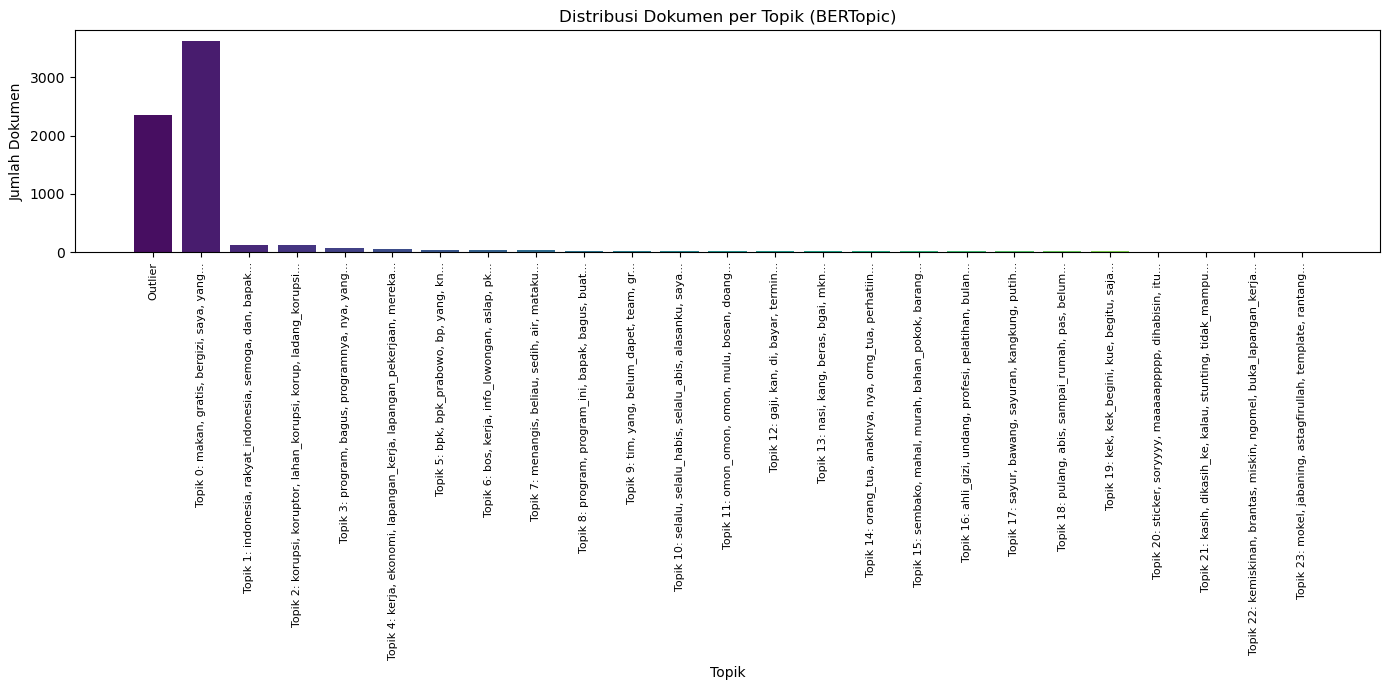

In [20]:
df_sampled['bertopic_modeling_topic'] = topics
df_sampled['bertopic_modeling_prob'] = max_probs

bertopic_topic_counts = df_sampled['bertopic_modeling_topic'].value_counts().sort_index()

plt.figure(figsize=(14, 7))
n_topics = len(bertopic_topic_counts)
colors = sns.color_palette('viridis', n_topics)

labels = []
for topic_id in bertopic_topic_counts.index:
    if topic_id == -1:
        labels.append('Outlier')
    else:
        topic_words = ', '.join([w for w, _ in topic_model.get_topic(topic_id)[:5]])
        labels.append(f'Topik {topic_id}: {topic_words}...')

bars = plt.bar(range(n_topics), bertopic_topic_counts.values, color=colors)
plt.xlabel('Topik')
plt.ylabel('Jumlah Dokumen')
plt.title('Distribusi Dokumen per Topik (BERTopic)')
plt.xticks(range(n_topics), labels, rotation=90, fontsize=8)

plt.tight_layout()
plt.savefig('output/bertopic_modeling_topic_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
n_real_topics = len([t for t in set(topics) if t != -1])
n_outliers = topics.count(-1)
outlier_pct = (n_outliers / len(topics)) * 100

non_outlier_topics = [t for t in topics if t != -1]
if len(set(non_outlier_topics)) > 1:
    valid_mask = [t != -1 for t in topics]
    embeddings = embedding_model.encode([t for t, v in zip(texts, valid_mask) if v])
    valid_topics = [t for t, v in zip(topics, valid_mask) if v]
    silhouette = silhouette_score(embeddings, valid_topics)
    print(f"Silhouette Score (non-outlier): {silhouette:.4f}")
else:
    silhouette = None
    print("Tidak cukup topik untuk hitung silhouette.")

print(f"\n=== Ringkasan BERTopic ===")
print(f"Jumlah topik (non-outlier): {n_real_topics}")
print(f"Jumlah outlier: {n_outliers} ({outlier_pct:.1f}%)")
print(f"Silhouette Score: {silhouette}")
if bertopic_coherence:
    print(f"Coherence Score (C_v): {bertopic_coherence:.4f}")
if bertopic_topic_diversity:
    print(f"Topic Diversity: {bertopic_topic_diversity:.4f}")

Silhouette Score (non-outlier): -0.0510

=== Ringkasan BERTopic ===
Jumlah topik (non-outlier): 24
Jumlah outlier: 2345 (34.6%)
Silhouette Score: -0.05101358890533447
Coherence Score (C_v): 0.4133
Topic Diversity: 0.7667


## 5. Evaluasi Model

In [22]:
lda_coherence = results_df.loc[results_df['k'] == best_k, 'coherence'].values[0]
lda_perplexity = results_df.loc[results_df['k'] == best_k, 'perplexity'].values[0]
lda_topic_diversity = results_df.loc[results_df['k'] == best_k, 'topic_diversity'].values[0]

evaluation_summary = pd.DataFrame({
    'Metrik': [
        'Coherence Score (C_v)',
        'Perplexity',
        'Topic Diversity',
        'Silhouette Score',
        'Jumlah Topik',
        'Outlier (%)',
        'Jumlah Dokumen'
    ],
    'LDA': [
        f'{lda_coherence:.4f}',
        f'{lda_perplexity:.2f}',
        f'{lda_topic_diversity:.4f}',
        'N/A',
        best_k,
        '0.0%',
        len(texts)
    ],
    'BERTopic': [
        f'{bertopic_coherence:.4f}' if bertopic_coherence else 'N/A',
        'N/A',
        f'{bertopic_topic_diversity:.4f}' if bertopic_topic_diversity else 'N/A',
        f'{silhouette:.4f}' if silhouette else 'N/A',
        n_real_topics,
        f'{outlier_pct:.1f}%',
        len(texts)
    ]
})
evaluation_summary.to_csv('output/evaluation_summary.csv', index=False)
evaluation_summary

,Metrik,LDA,BERTopic
0,Coherence Score (C_v),0.5098,0.4133
1,Perplexity,799.22,N/A
2,Topic Diversity,0.9000,0.7667
3,Silhouette Score,N/A,-0.0510
4,Jumlah Topik,8,24
5,Outlier (%),0.0%,34.6%
6,Jumlah Dokumen,6787,6787


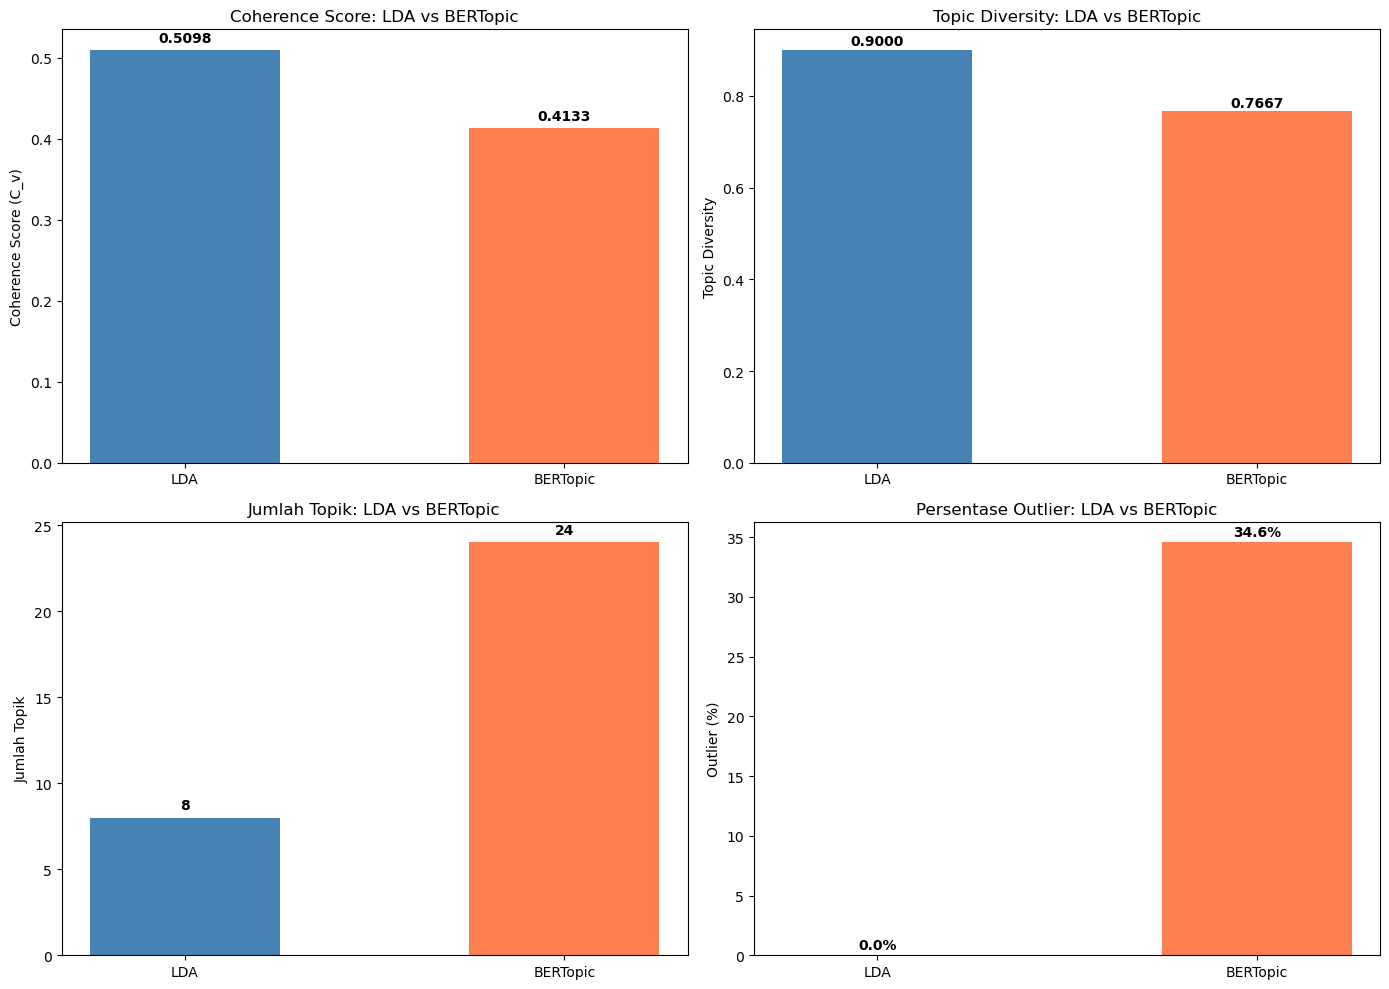

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = ['LDA', 'BERTopic']

coh_vals = [lda_coherence, bertopic_coherence if bertopic_coherence else 0]
axes[0, 0].bar(models, coh_vals, color=['steelblue', 'coral'], width=0.5)
axes[0, 0].set_ylabel('Coherence Score (C_v)')
axes[0, 0].set_title('Coherence Score: LDA vs BERTopic')
for i, v in enumerate(coh_vals):
    if v > 0:
        axes[0, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

td_vals = [lda_topic_diversity, bertopic_topic_diversity if bertopic_topic_diversity else 0]
axes[0, 1].bar(models, td_vals, color=['steelblue', 'coral'], width=0.5)
axes[0, 1].set_ylabel('Topic Diversity')
axes[0, 1].set_title('Topic Diversity: LDA vs BERTopic')
for i, v in enumerate(td_vals):
    if v > 0:
        axes[0, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

n_topics_vals = [best_k, n_real_topics]
axes[1, 0].bar(models, n_topics_vals, color=['steelblue', 'coral'], width=0.5)
axes[1, 0].set_ylabel('Jumlah Topik')
axes[1, 0].set_title('Jumlah Topik: LDA vs BERTopic')
for i, v in enumerate(n_topics_vals):
    axes[1, 0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

outlier_data = [0, outlier_pct]
axes[1, 1].bar(models, outlier_data, color=['steelblue', 'coral'], width=0.5)
axes[1, 1].set_ylabel('Outlier (%)')
axes[1, 1].set_title('Persentase Outlier: LDA vs BERTopic')
for i, v in enumerate(outlier_data):
    axes[1, 1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('output/model_evaluation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Interpretasi Manual Topik

In [24]:
interpretation_lda = []
print("=== INTERPRETASI MANUAL TOPIK LDA ===\n")
for topic_idx in range(best_k):
    topic_words_idx = best_lda.components_[topic_idx].argsort()[:-6:-1]
    top_words = [feature_names[i] for i in topic_words_idx]
    doc_count = (df_sampled['lda_best_topic'] == topic_idx).sum()
    doc_pct = (doc_count / len(texts)) * 100
    
    sample_docs = df_sampled[df_sampled['lda_best_topic'] == topic_idx]['text_final'].head(3).tolist()
    
    interpretation = {
        'model': 'LDA',
        'topic_id': topic_idx,
        'keywords': ', '.join(top_words),
        'doc_count': doc_count,
        'doc_pct': f'{doc_pct:.1f}%',
        'sample_1': sample_docs[0] if sample_docs else '',
        'sample_2': sample_docs[1] if len(sample_docs) > 1 else '',
        'sample_3': sample_docs[2] if len(sample_docs) > 2 else ''
    }
    interpretation_lda.append(interpretation)
    
    print(f"Topik {topic_idx} ({doc_count} dokumen, {doc_pct:.1f}%):")
    print(f"  Keywords: {', '.join(top_words)}")
    print(f"  Contoh dokumen:")
    for i, doc in enumerate(sample_docs, 1):
        print(f"    {i}. {doc[:150]}...")
    print()

interp_lda_df = pd.DataFrame(interpretation_lda)
interp_lda_df.to_csv('output/lda_topic_interpretation.csv', index=False)

=== INTERPRETASI MANUAL TOPIK LDA ===

Topik 0 (237 dokumen, 3.5%):
  Keywords: tahu, min, bpk_prabowo, omon, masya_allah
  Contoh dokumen:
    1. huuhhhhh...
    2. rarrrr...
    3. gercepp...

Topik 1 (177 dokumen, 2.6%):
  Keywords: pk, mokel, maju, lanjut, demi
  Contoh dokumen:
    1. mokel di jalan...
    2. bayyohh mokel berjamaah...
    3. lihat ginian doang ikut_bahagia...

Topik 2 (4208 dokumen, 62.0%):
  Keywords: makan, gratis, bergizi, yang, saya
  Contoh dokumen:
    1. makan bergizi gratis tidak hanya buat anak sekolah ya gaes ibu_hamil menyusui juga dpt...
    2. sbnrnya program makan bergizi gratis bagus yang meruesakny yang mengelolny tetapi tidak semua pengelola buruk ada juga yang amanah baik...
    3. makan bergizi gratis anak jadi semangat sekolah the_best p_prabowo...

Topik 3 (107 dokumen, 1.6%):
  Keywords: itu, enak, kapan, yang_penting, lapangan
  Contoh dokumen:
    1. mending di ganti beras sekarung...
    2. mereka se effort itu lohh...
    3. survei lapan

In [25]:
interpretation_bertopic = []
print("=== INTERPRETASI MANUAL TOPIK BERTopic ===\n")
for topic_id in topic_info['Topic'].values:
    if topic_id == -1:
        continue
    topic_words = topic_model.get_topic(topic_id)
    words = [w for w, _ in topic_words[:10]]
    doc_count = topic_info[topic_info['Topic'] == topic_id]['Count'].values[0]
    doc_pct = (doc_count / len(texts)) * 100
    
    sample_docs = df_sampled[df_sampled['bertopic_modeling_topic'] == topic_id]['text_final'].head(3).tolist()
    
    interpretation = {
        'model': 'BERTopic',
        'topic_id': topic_id,
        'keywords': ', '.join(words),
        'doc_count': doc_count,
        'doc_pct': f'{doc_pct:.1f}%',
        'sample_1': sample_docs[0] if sample_docs else '',
        'sample_2': sample_docs[1] if len(sample_docs) > 1 else '',
        'sample_3': sample_docs[2] if len(sample_docs) > 2 else ''
    }
    interpretation_bertopic.append(interpretation)
    
    print(f"Topik {topic_id} ({doc_count} dokumen, {doc_pct:.1f}%):")
    print(f"  Keywords: {', '.join(words)}")
    print(f"  Contoh dokumen:")
    for i, doc in enumerate(sample_docs, 1):
        print(f"    {i}. {doc[:150]}...")
    print()

interp_bertopic_df = pd.DataFrame(interpretation_bertopic)
interp_bertopic_df.to_csv('output/bertopic_topic_interpretation.csv', index=False)

=== INTERPRETASI MANUAL TOPIK BERTopic ===

Topik 0 (3622 dokumen, 53.4%):
  Keywords: makan, gratis, bergizi, saya, yang, anak, tidak, di, bapak, sekolah
  Contoh dokumen:
    1. makan bergizi gratis tidak hanya buat anak sekolah ya gaes ibu_hamil menyusui juga dpt...
    2. sbnrnya program makan bergizi gratis bagus yang meruesakny yang mengelolny tetapi tidak semua pengelola buruk ada juga yang amanah baik...
    3. saya guru paud sangat senang dengan program makan bergizi gratis tapii guru paud itu tidak dpt apa ya gaes berita ttg insetif yang didapat guru itu ha...

Topik 1 (122 dokumen, 1.8%):
  Keywords: indonesia, rakyat_indonesia, semoga, dan, bapak, presiden, yang, bapak_presiden, akan, ada
  Contoh dokumen:
    1. memang_benar guys coba banding kan anak indonesia yang di adopsi orang belanda itu postur nya jadi lebih tinggi besar karena kebutuhan gizi nya terpen...
    2. seluruh_indonesia januari februari tanggamus tidak ada gantian lah orang lain juga ingin ngerasain...
  

## 7. Simpan Hasil Modeling

In [26]:
df_sampled.to_csv('data/modeling_results_sampled.csv', index=False)
print(f"Hasil modeling disimpan ke: data/modeling_results_sampled.csv")
print(f"Jumlah baris: {len(df_sampled)}")

Hasil modeling disimpan ke: data/modeling_results_sampled.csv
Jumlah baris: 6787


In [27]:
import json

bertopic_save = {
    'topics': topics,
    'probs': max_probs.tolist(),
    'topic_info': topic_info.to_dict(),
    'n_topics': n_real_topics,
    'n_outliers': n_outliers,
    'silhouette': silhouette,
    'coherence': bertopic_coherence,
    'topic_diversity': bertopic_topic_diversity
}

with open('output/bertopic_modeling_metadata.json', 'w') as f:
    json.dump({k: (v.tolist() if isinstance(v, np.ndarray) else v) for k, v in bertopic_save.items()}, f, indent=2, default=str)

print("Metadata BERTopic disimpan ke: output/bertopic_modeling_metadata.json")

Metadata BERTopic disimpan ke: output/bertopic_modeling_metadata.json


In [28]:
print("\n=== RINGKASAN ===")
print(f"Dataset sampling: 50% dari {len(df)} -> {len(df_sampled)} dokumen")
print(f"\nLDA (k={best_k}):")
print(f"  - Coherence Score: {lda_coherence:.4f}")
print(f"  - Perplexity: {lda_perplexity:.2f}")
print(f"  - Topic Diversity: {lda_topic_diversity:.4f}")
print(f"\nBERTopic:")
print(f"  - Jumlah topik: {n_real_topics}")
print(f"  - Outlier: {n_outliers} ({outlier_pct:.1f}%)")
print(f"  - Silhouette Score: {silhouette}")
if bertopic_coherence:
    print(f"  - Coherence Score: {bertopic_coherence:.4f}")
if bertopic_topic_diversity:
    print(f"  - Topic Diversity: {bertopic_topic_diversity:.4f}")
print(f"\nOutput tersimpan di:")
print(f"  - data/modeling_results_sampled.csv")
print(f"  - output/evaluation_summary.csv")
print(f"  - output/lda_topic_interpretation.csv")
print(f"  - output/bertopic_topic_interpretation.csv")
print(f"  - output/model_evaluation_comparison.png")
print(f"  - output/lda_*.png")
print(f"  - output/bertopic_modeling_*.html")
print(f"  - output/bertopic_modeling_*.png")


=== RINGKASAN ===
Dataset sampling: 50% dari 13574 -> 6787 dokumen

LDA (k=8):
  - Coherence Score: 0.5098
  - Perplexity: 799.22
  - Topic Diversity: 0.9000

BERTopic:
  - Jumlah topik: 24
  - Outlier: 2345 (34.6%)
  - Silhouette Score: -0.05101358890533447
  - Coherence Score: 0.4133
  - Topic Diversity: 0.7667

Output tersimpan di:
  - data/modeling_results_sampled.csv
  - output/evaluation_summary.csv
  - output/lda_topic_interpretation.csv
  - output/bertopic_topic_interpretation.csv
  - output/model_evaluation_comparison.png
  - output/lda_*.png
  - output/bertopic_modeling_*.html
  - output/bertopic_modeling_*.png
